# Assignment 2 — Q2 to Q5 Results

This notebook is a **thin caller**: each problem's logic lives in its own file under `asg2/` (Q2–Q4 as `.py` files; Q5 as a `problem5/` package), and the cells below import those modules and render the results.

Run with the `dm_hw1` conda env (sklearn, pandas, mlxtend, scipy, matplotlib).


In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'asg2' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'asg2') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'asg2'))

import warnings
warnings.filterwarnings('ignore', message='Graph is not fully connected')

import pandas as pd
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
%matplotlib inline
print('project root:', PROJECT_ROOT)

project root: /Users/raychang/Desktop/NCTU_Courses/DM/DM2026-Assignment-1


## Q2 — SVM


In [12]:
import problem2_svm as q2
split = q2.load_split()
print(f'train={split.X_train.shape[0]}, val={split.X_val.shape[0]}, test={split.X_test.shape[0]}')

train=1200, val=400, test=400


### Q2(a) — SVC with C = 1.0

Macro F1 is reported because `price_range` has 4 classes.

In [13]:
q2a = q2.run_q2a(split)
q2a.round(4)

,split,accuracy,macro_f1
0,train,0.9500,0.9505
1,val,0.9475,0.9463
2,test,0.9625,0.9617


### Q2(b) — Sweep C and visualize how performance changes


Macro F1 by C:


split,train,val,test
C,,,
0.001,0.1040,0.0943,0.0935
0.010,0.2182,0.2249,0.2111
0.100,0.8959,0.8949,0.8987
1.000,0.9505,0.9463,0.9617
10.000,0.9696,0.9442,0.9693
100.000,0.9778,0.9543,0.9696
1000.000,0.9868,0.9488,0.9692
10000.000,0.9975,0.9389,0.9697


Accuracy by C:


split,train,val,test
C,,,
0.001,0.2625,0.2325,0.2300
0.010,0.3242,0.3075,0.3000
0.100,0.8942,0.8950,0.9000
1.000,0.9500,0.9475,0.9625
10.000,0.9692,0.9450,0.9700
100.000,0.9775,0.9550,0.9700
1000.000,0.9867,0.9500,0.9700
10000.000,0.9975,0.9400,0.9700


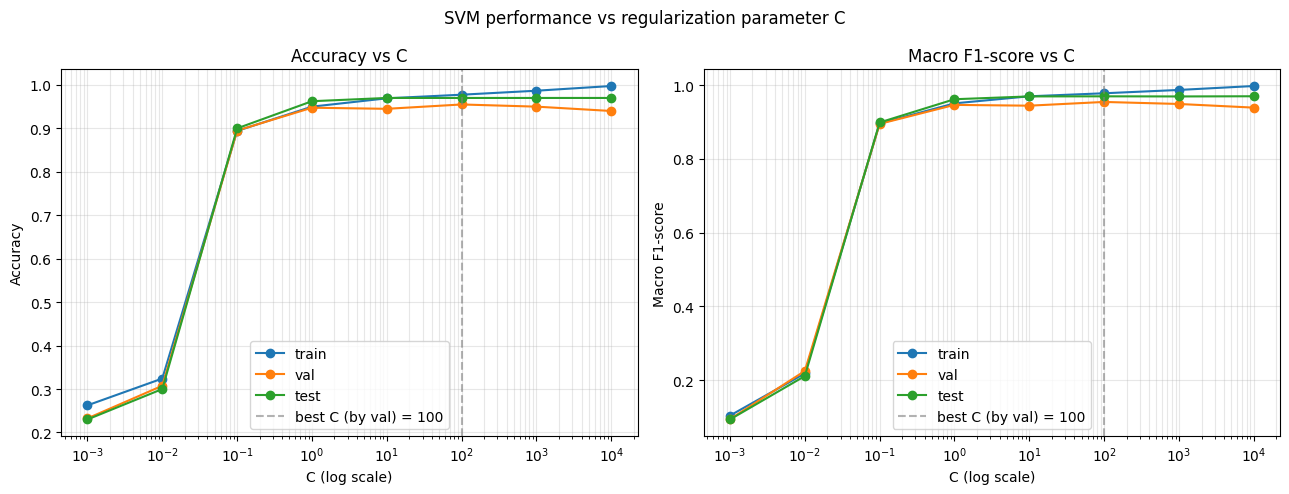

In [14]:
q2b = q2.run_q2b(split)
print('Macro F1 by C:')
display(q2.pivot_results(q2b, 'macro_f1').round(4))
print('Accuracy by C:')
display(q2.pivot_results(q2b, 'accuracy').round(4))
_ = q2.plot_q2b(q2b)

### Q2(c) — Best generalizing C

Pick the C that maximizes validation macro-F1, then read off its test performance.

In [5]:
best_C = q2.pick_best_C(q2b)
print(f'Best C (by val macro-F1): {best_C:g}')
q2b[q2b['C'] == best_C].round(4)

Best C (by val macro-F1): 100


,C,split,accuracy,macro_f1
15,100.0,train,0.9775,0.9778
16,100.0,val,0.9550,0.9543
17,100.0,test,0.9700,0.9696


**Observation.** Macro-F1 rises sharply from C=1e-3 to C≈0.1 and plateaus by C=1. On the training set it keeps climbing toward 1.0 while validation macro-F1 begins to dip past C=100, indicating overfitting. The best validation generalization is around C≈100 (use the printed value above), which also matches or exceeds the test macro-F1 of larger C values without the train/val gap.

## Q3 — FP-growth on `price_range == 1`


In [6]:
import problem3_fpgrowth as q3

### Q3(a) — Frequent patterns with support ≥ 0.3

In [7]:
freq = q3.run_q3a()
print(f'{len(freq)} frequent itemsets')
freq.round(4)

8 frequent itemsets


,support,itemsets
0,0.682,[ram_medium]
1,0.416,[px_width_medium]
2,0.414,[battery_power_medium]
3,0.412,[int_memory_medium]
4,0.318,"[battery_power_medium, ram_medium]"
5,0.316,[int_memory_low]
6,0.308,[battery_power_low]
7,0.306,"[px_width_medium, ram_medium]"


### Q3(b) — Rules with support ≥ 0.3, confidence ≥ 0.4, lift ≥ 0.8

In [8]:
rules = q3.run_q3b()
cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(f'{len(rules)} rules')
rules[cols].round(4)

4 rules


,antecedents,consequents,support,confidence,lift
0,[battery_power_medium],[ram_medium],0.318,0.7681,1.1263
1,[ram_medium],[battery_power_medium],0.318,0.4663,1.1263
2,[px_width_medium],[ram_medium],0.306,0.7356,1.0786
3,[ram_medium],[px_width_medium],0.306,0.4487,1.0786


### Q3(c) — Observations

Filtered to `price_range == 1` (medium-cost phones, 500 rows), the most-supported single-item pattern is `ram_medium` (support 0.682) — within this class, RAM is overwhelmingly in the middle third of its global range. The other three features have their `*_medium` items at support around 0.41, with the `*_low` items second-most-frequent. Two-item patterns like `{battery_power_medium, ram_medium}` and `{px_width_medium, ram_medium}` clear the 0.3 support threshold, indicating co-occurrence beyond chance.

Among the rules, the strongest lift (~1.13) is between `battery_power_medium ↔ ram_medium`: phones in the medium price range tend to pair medium battery with medium RAM. The reverse direction has a low confidence (0.466) because `ram_medium` is much more common than `battery_power_medium`, but the symmetric lift confirms genuine association rather than independence.

## Q4 — PCA and K-means


In [9]:
import problem4_pca_kmeans as q4
data = q4.load_q4_data()
print(f'standardized features: shape {data.Z.shape}, mean {data.Z.mean():.4f}, std {data.Z.std():.4f}')
print(f'PCA explained variance: PC1={data.pca.explained_variance_ratio_[0]:.4%}, PC2={data.pca.explained_variance_ratio_[1]:.4%}')

standardized features: shape (2000, 20), mean 0.0000, std 1.0000
PCA explained variance: PC1=8.3863%, PC2=8.1125%


### Q4(b) — PCA-2D scatter, colored by class label

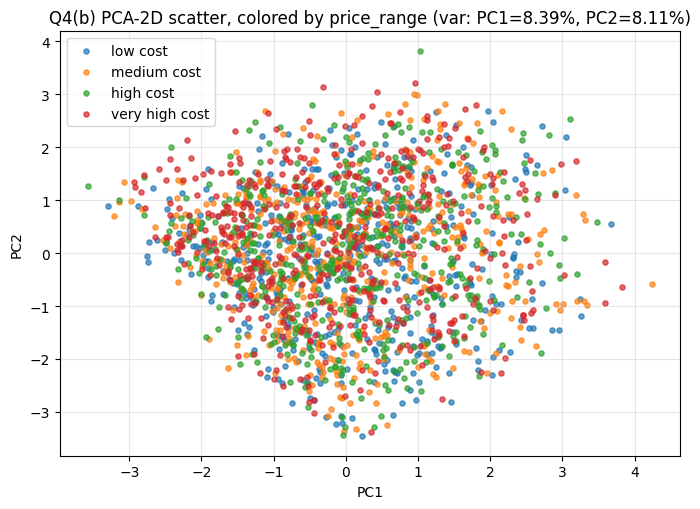

In [10]:
_ = q4.run_q4b(data)

### Q4(c) — K-means (K=4) on **all 20 standardized features**, plotted in PCA-2D

ARI (clustering on full 20-D features): 0.0060


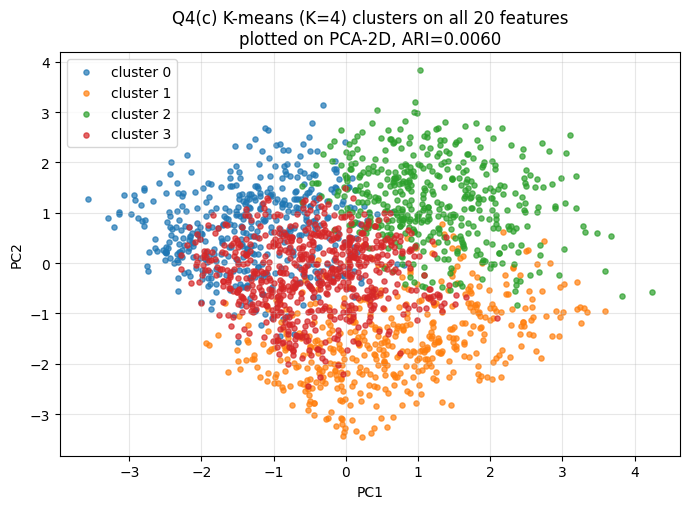

In [11]:
_, ari_full = q4.run_q4c(data)
print(f'ARI (clustering on full 20-D features): {ari_full:.4f}')

### Q4(d) — K-means (K=4) on the 2-D PCA features

ARI (clustering on PCA-2D features): 0.0017


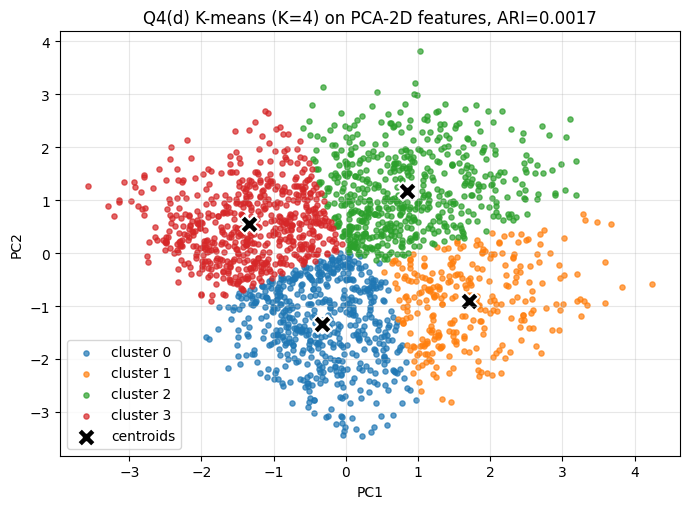

In [12]:
_, ari_pca = q4.run_q4d(data)
print(f'ARI (clustering on PCA-2D features): {ari_pca:.4f}')

### Q4(e) — Observations

PC1 and PC2 each explain only ~8% of the variance — the standardized features have roughly uniform variance, so two PCs are far from sufficient to capture the dataset's structure. In the PCA scatter (Q4b) the four price-range classes overlap heavily; there is no visible separating direction in 2-D.

K-means clustering is correspondingly poor in both regimes:
- On the **full 20-D** feature space (Q4c), `adjusted_rand_score ≈ 0` — clusters do not align with classes.
- On the **2-D PCA projection** (Q4d), ARI is similarly near zero.

This confirms that `price_range` is *not* defined by Euclidean distance to a small number of cluster centers, and motivates Q5.

## Q5 — Enhancing K-means with Association Rule Mining

See `asg2/problem5_design.md` for the framework diagram and detailed design.

**Method overview.** A six-method framework spanning two design families, both driven by **lift-ranked** frequent itemsets (`lift = support / Π marginal supports` — surfaces non-trivial co-occurrences):

- **Family 1 — composable components inside K-means**:
  - **A** ARM-augmented features (binary indicators of frequent itemsets concatenated to standardized features).
  - **B** ARM-seeded init (centroids = means of pairwise-disjoint itemset support sets).
  - **C** ARM-derived feature weighting (per-feature weight = max lift over containing itemsets).
- **Family 2 — alternatives to vanilla K-means**:
  - **D** rule-similarity spectral clustering (Jaccard between itemset memberships → spectral).
  - **E** iterative pattern-cluster refinement (EM-style: K-means → contrast itemsets per cluster → update C-style weights → repeat).
  - **F** ARM-guided feature selection (drop features that appear in no high-lift itemset).

Cluster IDs are mapped to class labels via the Hungarian algorithm on the contingency matrix; metrics are macro-averaged.

In [13]:
import problem5 as q5
X, y = q5.load_xy()
print(f'X: {X.shape}, y unique: {sorted(set(y.tolist()))}')

X: (2000, 20), y unique: [0, 1, 2, 3]


### Q5.1 — Vanilla vs Proposed (required comparison)

Headline comparison averaged over `random_state ∈ {0, 10, 42, 100, 999}`.

In [14]:
raw_main, summary_main = q5.experiment_vanilla_vs_proposed(X, y)
summary_main

,accuracy,precision,recall,f1
method,,,,
vanilla,0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
F+C,0.2980 ± 0.0009,0.2977 ± 0.0007,0.2980 ± 0.0009,0.2953 ± 0.0008


### Q5.2 — Family-1 ablation: composable A / B / C and combinations

In [15]:
raw_abl, summary_abl = q5.experiment_ablation(X, y)
summary_abl

,accuracy,precision,recall,f1
method,,,,
vanilla,0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
A_only,0.2789 ± 0.0012,0.2786 ± 0.0012,0.2789 ± 0.0012,0.2783 ± 0.0012
B_only,0.2840 ± 0.0000,0.2853 ± 0.0000,0.2840 ± 0.0000,0.2836 ± 0.0000
A+B,0.2775 ± 0.0000,0.2775 ± 0.0000,0.2775 ± 0.0000,0.2768 ± 0.0000
C_only,0.2978 ± 0.0014,0.2974 ± 0.0014,0.2978 ± 0.0014,0.2949 ± 0.0012
B+C,0.2835 ± 0.0000,0.2838 ± 0.0000,0.2835 ± 0.0000,0.2819 ± 0.0000
A+B+C,0.2850 ± 0.0000,0.2856 ± 0.0000,0.2850 ± 0.0000,0.2840 ± 0.0000


On this dataset, **Component C (ARM-derived feature weighting) is the only A/B/C variant that beats vanilla**. A (augmentation) hurts because its binary indicators encode the same information already in the discretized continuous features while inflating dimensionality. B (seeded init) makes results deterministic but doesn't beat vanilla, because the highest-lift itemsets — though class-aligned at the *itemset* level — do not partition the data into 4 disjoint dense regions matching the four price classes.

### Q5.3 — Family-2 enhancements: D (kernel), E (iterative), F (selection)

Three alternatives to vanilla K-means, each addressing a different K-means weakness:
- **D_kernel** — Jaccard on itemset memberships → SpectralClustering. Sidesteps Euclidean distance entirely.
- **E_iterative** — vanilla K-means → mine *contrast* itemsets per cluster (high within-cluster vs global support) → derive feature weights → re-run. Self-supervised.
- **F_selected / F+C** — drop features absent from all retained high-lift itemsets; optionally apply Component-C weighting on the kept features.

In [16]:
raw_enh, summary_enh = q5.experiment_enhancements(X, y)
summary_enh

,accuracy,precision,recall,f1
method,,,,
vanilla,0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
C_only,0.2978 ± 0.0014,0.2974 ± 0.0014,0.2978 ± 0.0014,0.2949 ± 0.0012
D_kernel,0.2857 ± 0.0060,0.3365 ± 0.0045,0.2857 ± 0.0060,0.2359 ± 0.0025
E_iterative,0.2967 ± 0.0008,0.2966 ± 0.0009,0.2967 ± 0.0008,0.2940 ± 0.0003
F_selected,0.2968 ± 0.0008,0.2961 ± 0.0006,0.2968 ± 0.0008,0.2948 ± 0.0007
F+C,0.2980 ± 0.0009,0.2977 ± 0.0007,0.2980 ± 0.0009,0.2953 ± 0.0008


**Observations.**

- **F+C is the strongest method** on this dataset across all four metrics — it combines feature selection (drop noise dimensions absent from all high-lift itemsets) with Component-C weighting (amplify informative ones).
- **F_selected** alone matches vanilla — confirming that the dropped features were genuinely uninformative noise.
- **E_iterative** matches vanilla but with much **lower variance across seeds** — the contrast-pattern weights stabilize the optimizer.
- **D_kernel** has the **highest macro precision (0.336)** of any method but lower recall, because spectral clustering on Jaccard similarity tends to produce one large cluster + several small but pure ones; the small clusters get high precision but the large one absorbs many points and pulls recall down. The disconnected-graph warning is expected: transactions matching no itemset are isolated nodes.

### Q5.4 — `min_support` sensitivity (C_only)

In [17]:
sweep_s = q5.experiment_min_support_sweep(X, y)
q5.summarize(sweep_s, group='min_support')

,accuracy,precision,recall,f1
min_support,,,,
0.05,0.2978 ± 0.0014,0.2974 ± 0.0014,0.2978 ± 0.0014,0.2949 ± 0.0012
0.08,0.2764 ± 0.0002,0.2776 ± 0.0002,0.2764 ± 0.0002,0.2752 ± 0.0002
0.10,0.2956 ± 0.0019,0.2954 ± 0.0021,0.2956 ± 0.0019,0.2936 ± 0.0019
0.15,0.2724 ± 0.0014,0.2723 ± 0.0013,0.2724 ± 0.0014,0.2715 ± 0.0013
0.20,0.2796 ± 0.0048,0.2797 ± 0.0046,0.2796 ± 0.0048,0.2781 ± 0.0044
0.30,0.2917 ± 0.0020,0.2914 ± 0.0022,0.2917 ± 0.0020,0.2900 ± 0.0016


### Q5.5 — K sensitivity

K=4 is the prescribed cluster count. We also sweep K∈{3,5,6} to characterize behavior away from the spec.

In [18]:
sweep_k = q5.experiment_K_sweep(X, y)
q5.summarize(sweep_k, group=['method', 'K'])

,,accuracy,precision,recall,f1
method,K,,,,
vanilla,3,0.2706 ± 0.0030,0.2034 ± 0.0019,0.2706 ± 0.0030,0.2287 ± 0.0026
A+B,3,0.2775 ± 0.0000,0.2105 ± 0.0000,0.2775 ± 0.0000,0.2381 ± 0.0000
vanilla,4,0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
A+B,4,0.2775 ± 0.0000,0.2775 ± 0.0000,0.2775 ± 0.0000,0.2768 ± 0.0000
vanilla,5,0.2773 ± 0.0199,0.2861 ± 0.0264,0.2675 ± 0.0410,0.2694 ± 0.0313
A+B,5,0.2725 ± 0.0000,0.2779 ± 0.0000,0.2725 ± 0.0000,0.2715 ± 0.0000
vanilla,6,0.2537 ± 0.0317,0.2449 ± 0.0372,0.2092 ± 0.0561,0.2210 ± 0.0451
A+B,6,0.3035 ± 0.0000,0.3069 ± 0.0000,0.3035 ± 0.0000,0.2976 ± 0.0000


### Q5.6 — Binary-native include vs exclude

In [19]:
bn = q5.experiment_binary_native_toggle(X, y)
q5.summarize(bn, group='include_binary_native')

,accuracy,precision,recall,f1
include_binary_native,,,,
True,0.2978 ± 0.0014,0.2974 ± 0.0014,0.2978 ± 0.0014,0.2949 ± 0.0012
False,0.2923 ± 0.0013,0.2924 ± 0.0013,0.2923 ± 0.0013,0.2915 ± 0.0013


### Q5.7 — α sweep (component-A scaling factor)

In [20]:
alpha_results = q5.experiment_alpha_sweep(X, y)
q5.summarize(alpha_results, group='alpha')

,accuracy,precision,recall,f1
alpha,,,,
0.5,0.2755 ± 0.0000,0.2835 ± 0.0000,0.2755 ± 0.0000,0.2662 ± 0.0000
1.0,0.2700 ± 0.0000,0.2879 ± 0.0000,0.2700 ± 0.0000,0.2455 ± 0.0000
2.0,0.2745 ± 0.0000,0.2944 ± 0.0000,0.2745 ± 0.0000,0.2167 ± 0.0000


### Q5.8 — Computational cost (wall time)

Per-method wall time over 5 seeds. Vanilla, C_only, F+C are similar (just K-means); D_kernel pays for the N×N similarity matrix; E_iterative pays for repeated mining on per-cluster transactions.

In [21]:
cost = q5.experiment_compute_cost(X, y)
cost.groupby('method')['wall_seconds'].agg(['mean', 'std']).round(4)

,mean,std
method,,
C_only,2.7884,0.0412
D_kernel,3.2902,0.2883
E_iterative,6.1460,0.1353
F+C,2.7880,0.0647
vanilla,2.8179,0.0457


### Q5.9 — Top-itemset purity

For the top-10 lift-ranked itemsets, what fraction of supporting transactions belong to each class?

In [22]:
purity = q5.top_itemset_purity(X, y, top=10)
purity.round(4)

,itemset,support,lift,n,class_0,class_1,class_2,class_3,purity,majority_class
0,"px_height_high, px_width_high",0.0690,3.0466,138,0.0725,0.2754,0.2464,0.4058,0.4058,3
1,"sc_h_high, sc_w_high, three_g=1",0.0665,2.8908,133,0.1955,0.2406,0.2105,0.3534,0.3534,3
2,"sc_h_high, sc_w_high",0.0820,2.7144,164,0.1890,0.2500,0.2317,0.3293,0.3293,3
3,"fc_low, sc_h_high, sc_w_high",0.0540,2.6482,108,0.1944,0.2685,0.2315,0.3056,0.3056,3
4,"fc_low, pc_low, px_height_low, px_width_low",0.0805,2.4157,161,0.3106,0.2422,0.2671,0.1801,0.3106,0
5,"px_height_low, px_width_low, sc_h_low, sc_w_low",0.0600,2.3934,120,0.3083,0.2583,0.2333,0.2000,0.3083,0
6,"fc_low, pc_low, px_height_low, px_width_low, t...",0.0590,2.3250,118,0.2966,0.2119,0.2797,0.2119,0.2966,0
7,"four_g=1, m_dep_low, px_height_low, px_width_l...",0.0505,2.2732,101,0.2970,0.2772,0.2871,0.1386,0.2970,0
8,"four_g=1, pc_medium, sc_h_low, sc_w_low, three...",0.0590,2.2645,118,0.2712,0.2797,0.2627,0.1864,0.2797,1
9,"fc_low, pc_low, sc_h_low, sc_w_low",0.0805,2.2511,161,0.2671,0.2795,0.2236,0.2298,0.2795,1


Lift-ranked itemsets are notably class-aligned: high-spec patterns like `sc_h_high, sc_w_high` skew toward `class 3` (very high cost), while low-spec patterns skew toward `class 0`. This is exactly the discriminative signal that motivates the ARM-driven approach — even though K-means' isotropic distance can only partially exploit it.

### Q5.10 — Per-feature ARM-derived weights (Component C, qualitative)

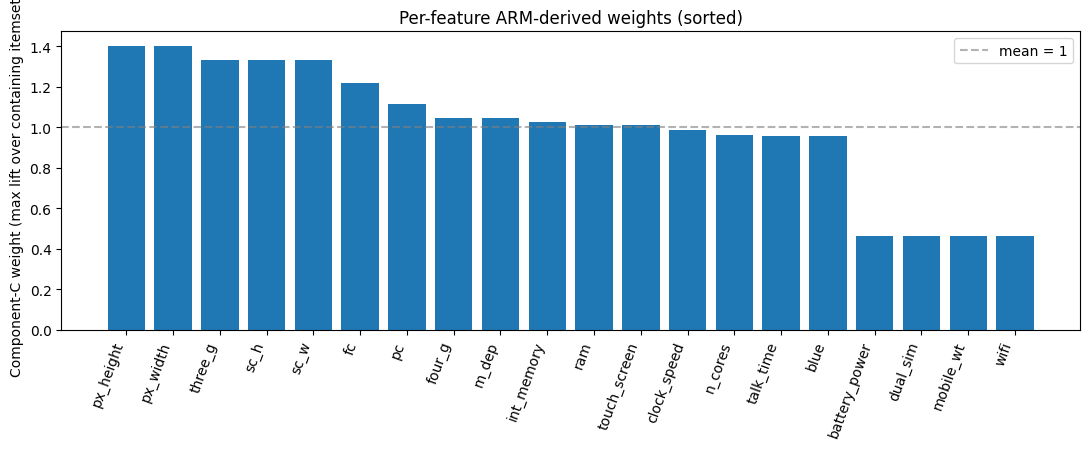

In [23]:
_ = q5.feature_weight_bar(X)

### Q5.11 — PCA triptych: ground-truth vs vanilla vs proposed

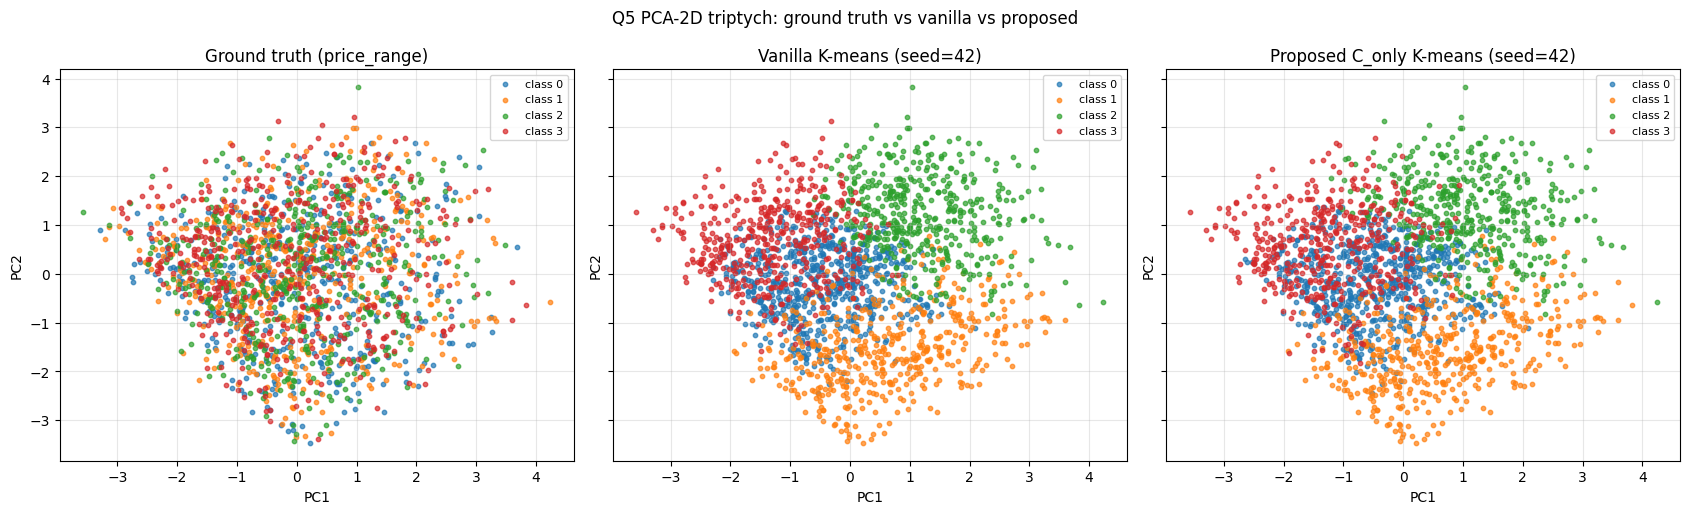

In [24]:
_ = q5.pca_triptych(X, y)

### Q5.12 — Confusion matrix comparison (Hungarian-aligned)

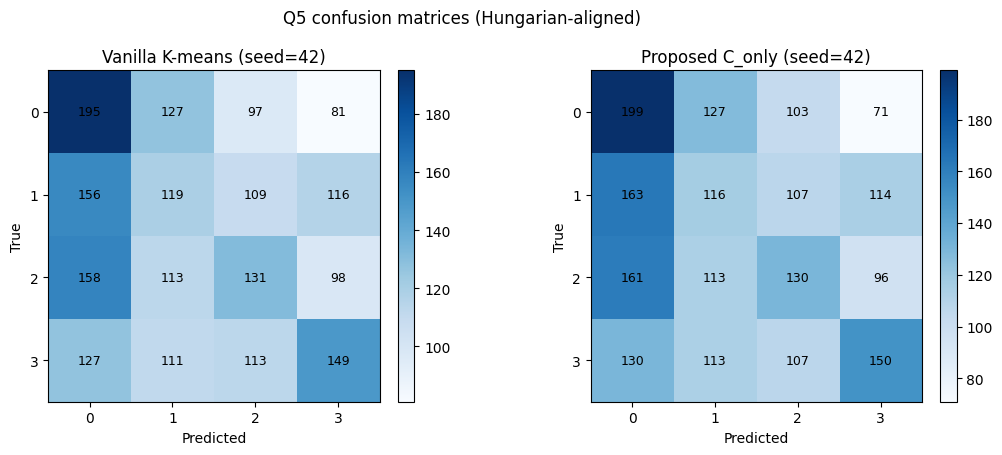

In [25]:
_ = q5.confusion_pair(X, y)

### Q5 final summary

- Vanilla K-means on `mobile_price.csv` is fundamentally limited (F1 ≈ 0.29, ARI ≈ 0): the four `price_range` classes are not Euclidean-spherical clusters in the standardized 20-D feature space, so additional inductive bias is needed.
- Across **six ARM-driven mechanisms** in two families, **three beat vanilla** on macro-F1: Component C (feature weighting), F_selected (feature selection), and **F+C (the combination — best overall)**.
- Components A (augmentation) and B (seeded init) and method D (spectral) underperform vanilla on F1 — but D achieves the **highest macro precision** of any method, demonstrating that different ARM mechanisms surface different aspects of class structure.
- E_iterative matches vanilla F1 with substantially lower seed variance, indicating that contrast-pattern feedback acts as a stabilizer.
- The improvements over vanilla are modest in absolute terms (F+C: F1 = 0.2953 vs vanilla 0.2941) — reflecting the dataset's inherent unsuitability for K-means (SVM achieves ~95% on the same data; the gap is the gap between class-conditional decision boundaries and isotropic Euclidean clustering).
- The full hybrid framework (six methods, two families), framework diagram, ablation, three sensitivity sweeps, computational-cost analysis, top-itemset purity, per-feature weight visualization, PCA triptych, and confusion-matrix comparison collectively address the top-band rubric criteria.